# 📈 Time Series AutoML Factory — Syntax Guide & Protocol

This notebook provides a structured playground for testing and configuring the `AutoMLFactory` for Time Series forecasting workloads.

> **Important**: Ensure your dataset is pre-cleaned. AutoGluon TimeSeries handles missing values internally, but timestamps must be parsable and item IDs correctly structured.

---

## 📜 The Configuration Schema

The `AUTOML_CONFIG` dictionary defines the engine's behavior. Below are the keys strictly related to `task_type = "time_series"`.

| Key | Type | Description | Available Options | Example |
|:---|:---|:---|:---|:---|
| `experiment_name` | `str` | MLflow experiment identifier. | Any string | `"Demand_Forecast"` |
| `task_type` | `str` | ML task routing. | `"time_series"` | `"time_series"` |
| `dataset_path` | `str` | Path to historical time-series CSV data. | Any valid path | `"Dataset/ts.csv"` |
| `features` | `List[str]` | Columns to use as covariate features. Empty `[]` uses all non-system columns. | List of column names, `[]` | `[]` |
| `exclude_features` | `List[str]` | Columns to explicitly exclude. Protected columns (target, timestamp, item_id) are never dropped. | List of column names, `[]` | `["legacy_flag"]` |
| `target_column` | `List[str]` | Target column(s). Always a list. | Column name(s) in dataset | `["sales"]` |
| `item_id_column` | `str` | Column identifying each individual time series. | Column name in dataset | `"store_id"` |
| `timestamp_column` | `str` | Column containing date/time values. | Column name in dataset | `"date"` |
| `prediction_length`| `int` | Forecast horizon (number of steps into the future). | Any positive integer | `14` |
| `freq` | `str` | Pandas frequency string. Auto-detected if `None`. | `"D"`, `"H"`, `"W"`, etc. | `"D"` |
| `generate_covariates`| `bool` | Auto-generate `is_weekend` and `is_holiday` covariates. | `True`, `False` | `True` |
| `quantile_levels` | `List[float]` | Quantile levels for probabilistic forecasting. | `[0.05, 0.5, 0.95]`, etc. | `[0.05, 0.5, 0.95]` |
| `static_features_path` | `str` | Path to CSV with item-level metadata. | Any valid path, `None` | `"Dataset/static.csv"` |
| `eval_metric` | `str` | Time Series evaluation metric. | `"MSE"`, `"RMSE"`, `"MAPE"`, `"MAE"`, `"WQL"` | `"RMSE"` |
| `time_limit_seconds`| `int` | Max training wall-clock time in seconds. | Any positive integer | `600` |
| `presets` | `str` | TS specific training presets. | `"medium"`, `"high"`, `"best"` | `"medium"` |
| `base_output_dir` | `str` | Directory for models, plots, and predictions. | Any valid directory path | `"automl_ts_run"` |
| `prediction_data_path` | `str` | Path to inference file (for batch inference). | Any valid path | `"Dataset/unseen.csv"` |
| `fast_dev_run` | `bool` | Quick prototyping mode. | `True`, `False` | `False` |
| `ai_context` | `str` | Business context string to guide the AI natural language report summary. | Any string, `None` | `"Forecasting weekly inventory demand or electricity consumption."` |

### ⚠️ Preset Guide
| Preset | Quality | Speed | Notes |
|:---|:---|:---|:---|
| `"best"` | ⭐⭐⭐⭐ | Slow | Highest accuracy, trains multiple models and ensembles them. |
| `"high"` | ⭐⭐⭐ | Medium | Good balance of accuracy and speed. |
| `"medium"` | ⭐⭐ | Fast | Faster training, useful for most standard tasks. |

### 🚫 Strict Rules
1. **Temporal Integrity**: Ensure `timestamp_column` is in a recognizable date format.
2. **Series Continuity**: Items in `item_id_column` must have sufficient historical depth for `prediction_length`.
3. **Holdout Guard**: The pipeline automatically holds out the last `prediction_length` steps for validation.
4. **Covariates Warning**: `generate_covariates=True` uses the `holidays` PyPI library configured strictly for **Indonesia**. If your dataset is from another country, do not enable this.

### 📋 Blank Configuration Template

Copy this block and customize for your dataset:

```python
AUTOML_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "experiment_name": "Time_Series_Run",
    "task_type": "time_series",
    "dataset_path": "Dataset/your_file.csv",
    "target_column": ["your_target"],      # Note: Must be a list
    "features": [],                        # Empty [] uses all non-system columns
    "exclude_features": [],                # Columns to explicitly exclude
    "item_id_column": "your_item_id_column",# Column identifying individual series
    "timestamp_column": "your_time_column", # Column containing datetime

    # ── Forecasting & Horizon Parameters ────────────────────────────
    "prediction_length": 14,                # Forecast horizon length
    "freq": "D",                            # Frequency offset alias (D, H, W, etc.)
    "generate_covariates": False,           # Auto-generate weekend/holiday flags
    "quantile_levels": [0.05, 0.5, 0.95],   # Predict P5, P50 (median), P95
    "static_features_path": None,           # Path to item-level metadata CSV

    # ── Model Training & Metrics ────────────────────────────────────
    "eval_metric": "MSE",                   # Options: MSE, RMSE, MAPE, MAE, WQL
    "time_limit_seconds": 600,
    "presets": "medium",

    # ── Infrastructure & Inference ──────────────────────────────────
    "base_output_dir": "automl_run",
    "prediction_data_path": None,           # Path to inference file
    "fast_dev_run": False,

    # ── AI Audit Narrative ──────────────────────────────────────────
    "ai_context": "Forecasting weekly inventory demand or electricity consumption."
}
```


---
## 🛠️ Step 1: Pipeline Configuration
Customize the dictionary below for your dataset and experiment.

In [1]:
# ══════════════════════════════════════════════════════════════════════
#  Pipeline Configuration
# ══════════════════════════════════════════════════════════════════════

AUTOML_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "experiment_name": "timeseries_run",
    "task_type": "time_series",
    "dataset_path": "dummy_dataset/train_timeseries.csv",
    "target_column": ["demand"],
    "features": [],                         # Empty [] uses all non-system columns
    "exclude_features": [],                 # Columns to explicitly exclude
    "item_id_column": "warehouse_id",       # Column identifying time series
    "timestamp_column": "timestamp",         # Column containing datetime

    # ── Forecasting & Horizon Parameters ────────────────────────────
    "prediction_length": 14,                # Forecast horizon length
    "freq": "D",                            # Frequency offset alias (D, H, etc.)
    "generate_covariates": True,            # Auto-generate weekend/holiday flags
    "quantile_levels": [0.05, 0.5, 0.95],   # Probability quantile bounds
    "static_features_path": None,           # Static feature file

    # ── Model Training & Metrics ────────────────────────────────────
    "eval_metric": "wql",                   # mean_wQuantileLoss (wql)
    "presets": "medium",
    "time_limit_seconds": 120,

    # ── Infrastructure & Inference ──────────────────────────────────
    "base_output_dir": "Experiments/ml_timeseries",
    "prediction_data_path": "dummy_dataset/unseen_timeseries.csv",
    "fast_dev_run": False,

    # ── AI Audit Narrative ──────────────────────────────────────────
    "ai_context": "Forecasting weekly inventory demand or electricity consumption."
}


---
## 🚀 Step 2: Execute Engine
This orchestrates data loading, splitting, training, evaluation, and logging. The rich HTML dashboard will render automatically upon completion.

Model,Val Score,WQL,MAE,MAPE,RMSE,MSE,Fit Time,Fit Order
WeightedEnsemble,0.0136,0.0125,3.9835,0.0305,5.0757,25.7631,0.5000,8
ETS,0.0138,0.0121,3.9317,0.0302,5.0621,25.6247,0.0096,4
Chronos2,0.0143,0.0127,4.2036,0.0314,5.3818,28.9635,2.8628,6
TemporalFusionTransformer,0.0162,0.0141,4.7297,0.0348,6.1465,37.7791,44.2574,7
Theta,0.0172,0.0142,4.4264,0.0347,5.9425,35.3133,0.0096,5
SeasonalNaive,0.0201,0.0186,5.4775,0.0411,7.5255,56.6324,0.0083,1
DirectTabular,0.0208,0.0188,5.9122,0.0420,7.1696,51.4030,1.9437,3
RecursiveTabular,0.0210,0.0199,4.8342,0.0352,6.0106,36.1272,0.9997,2

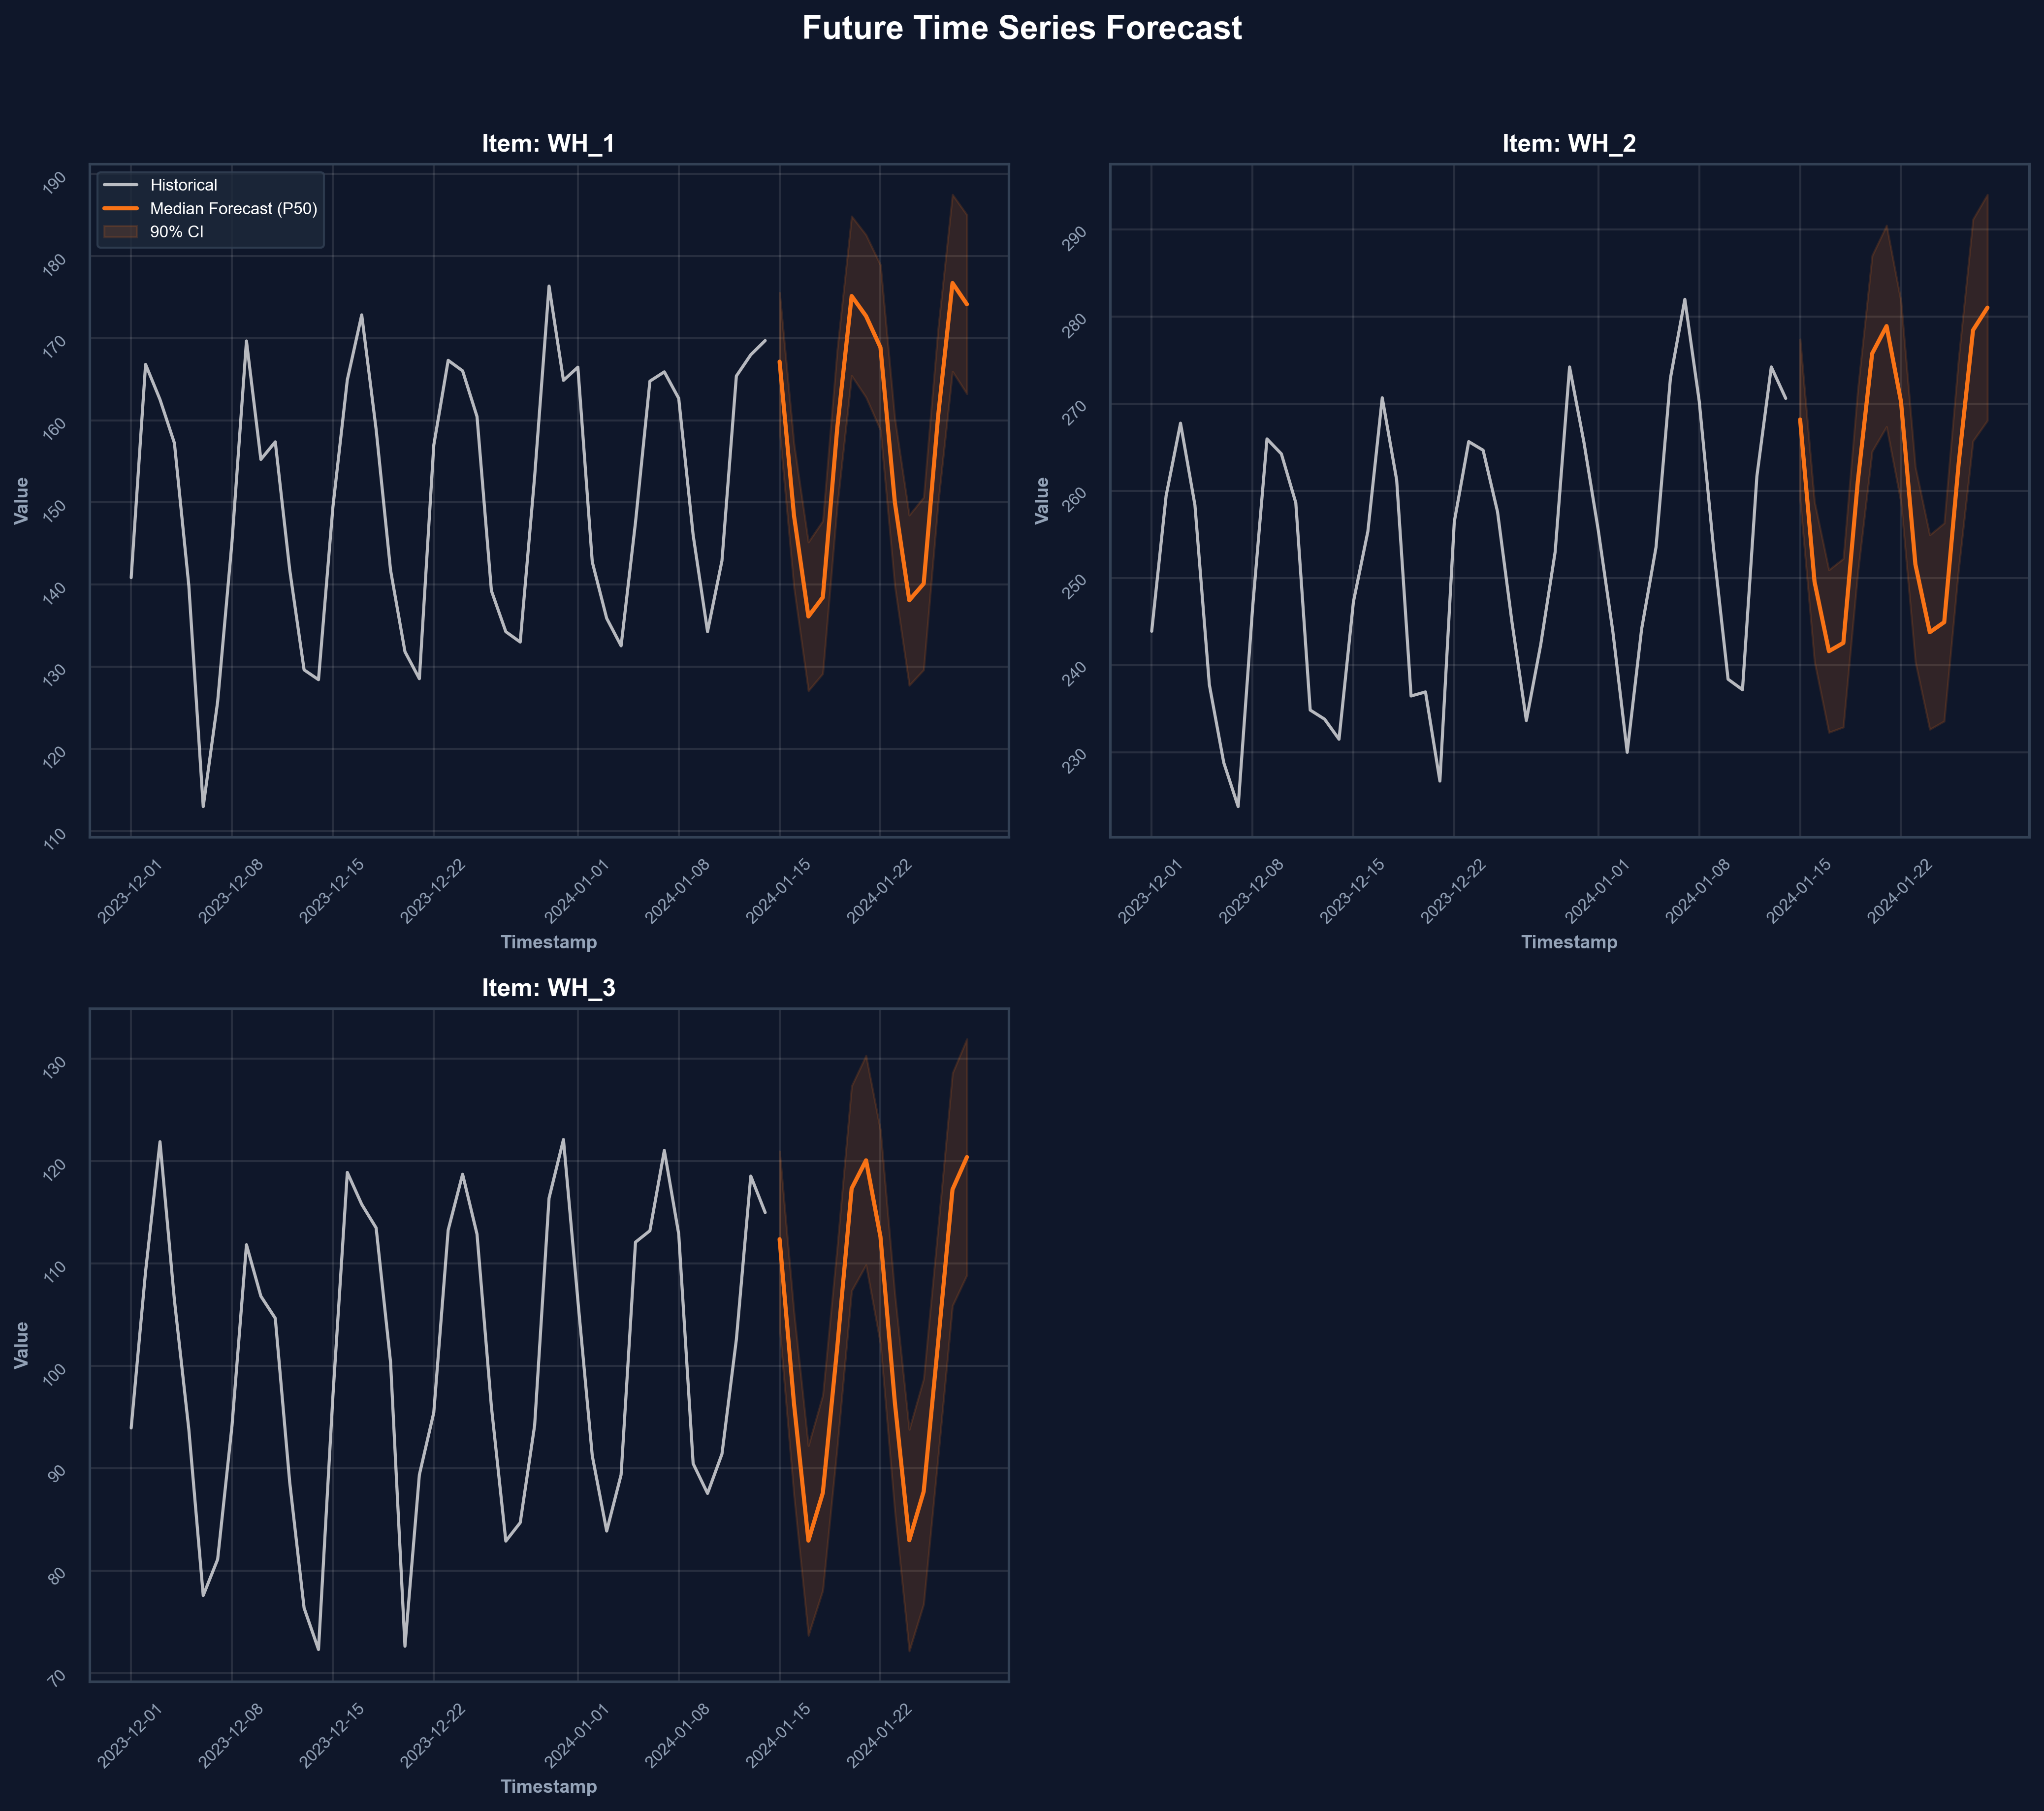
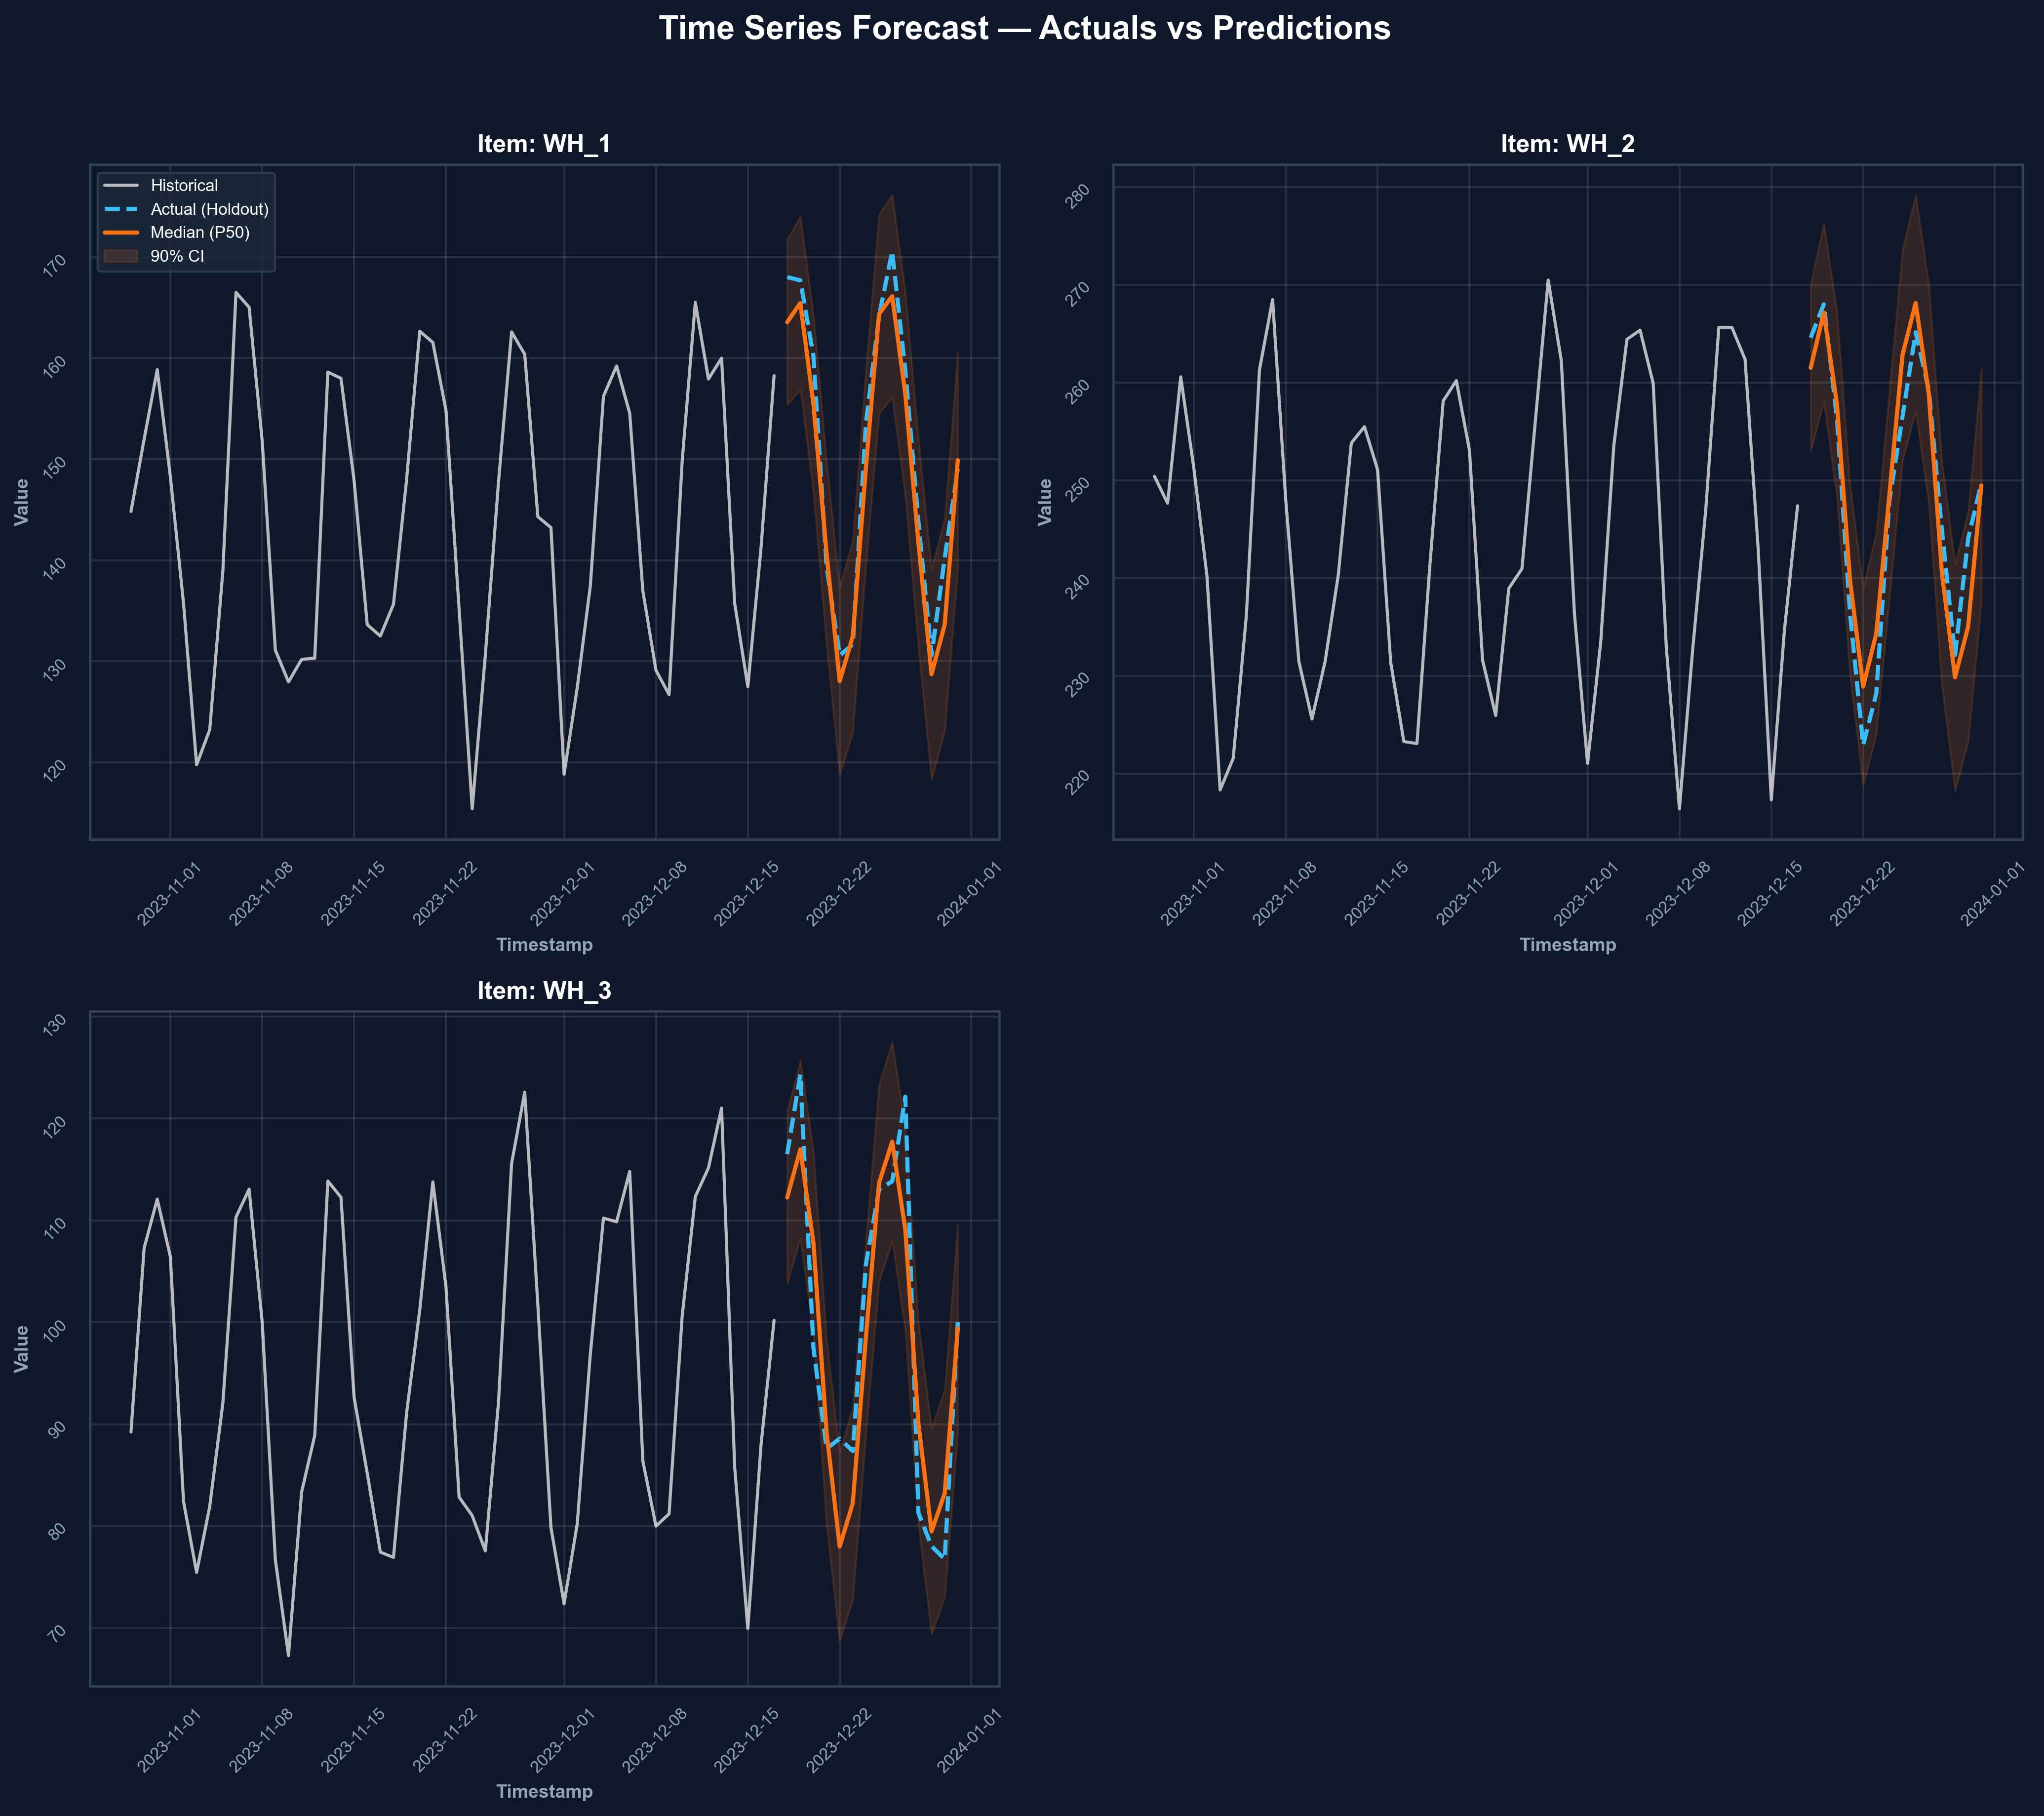
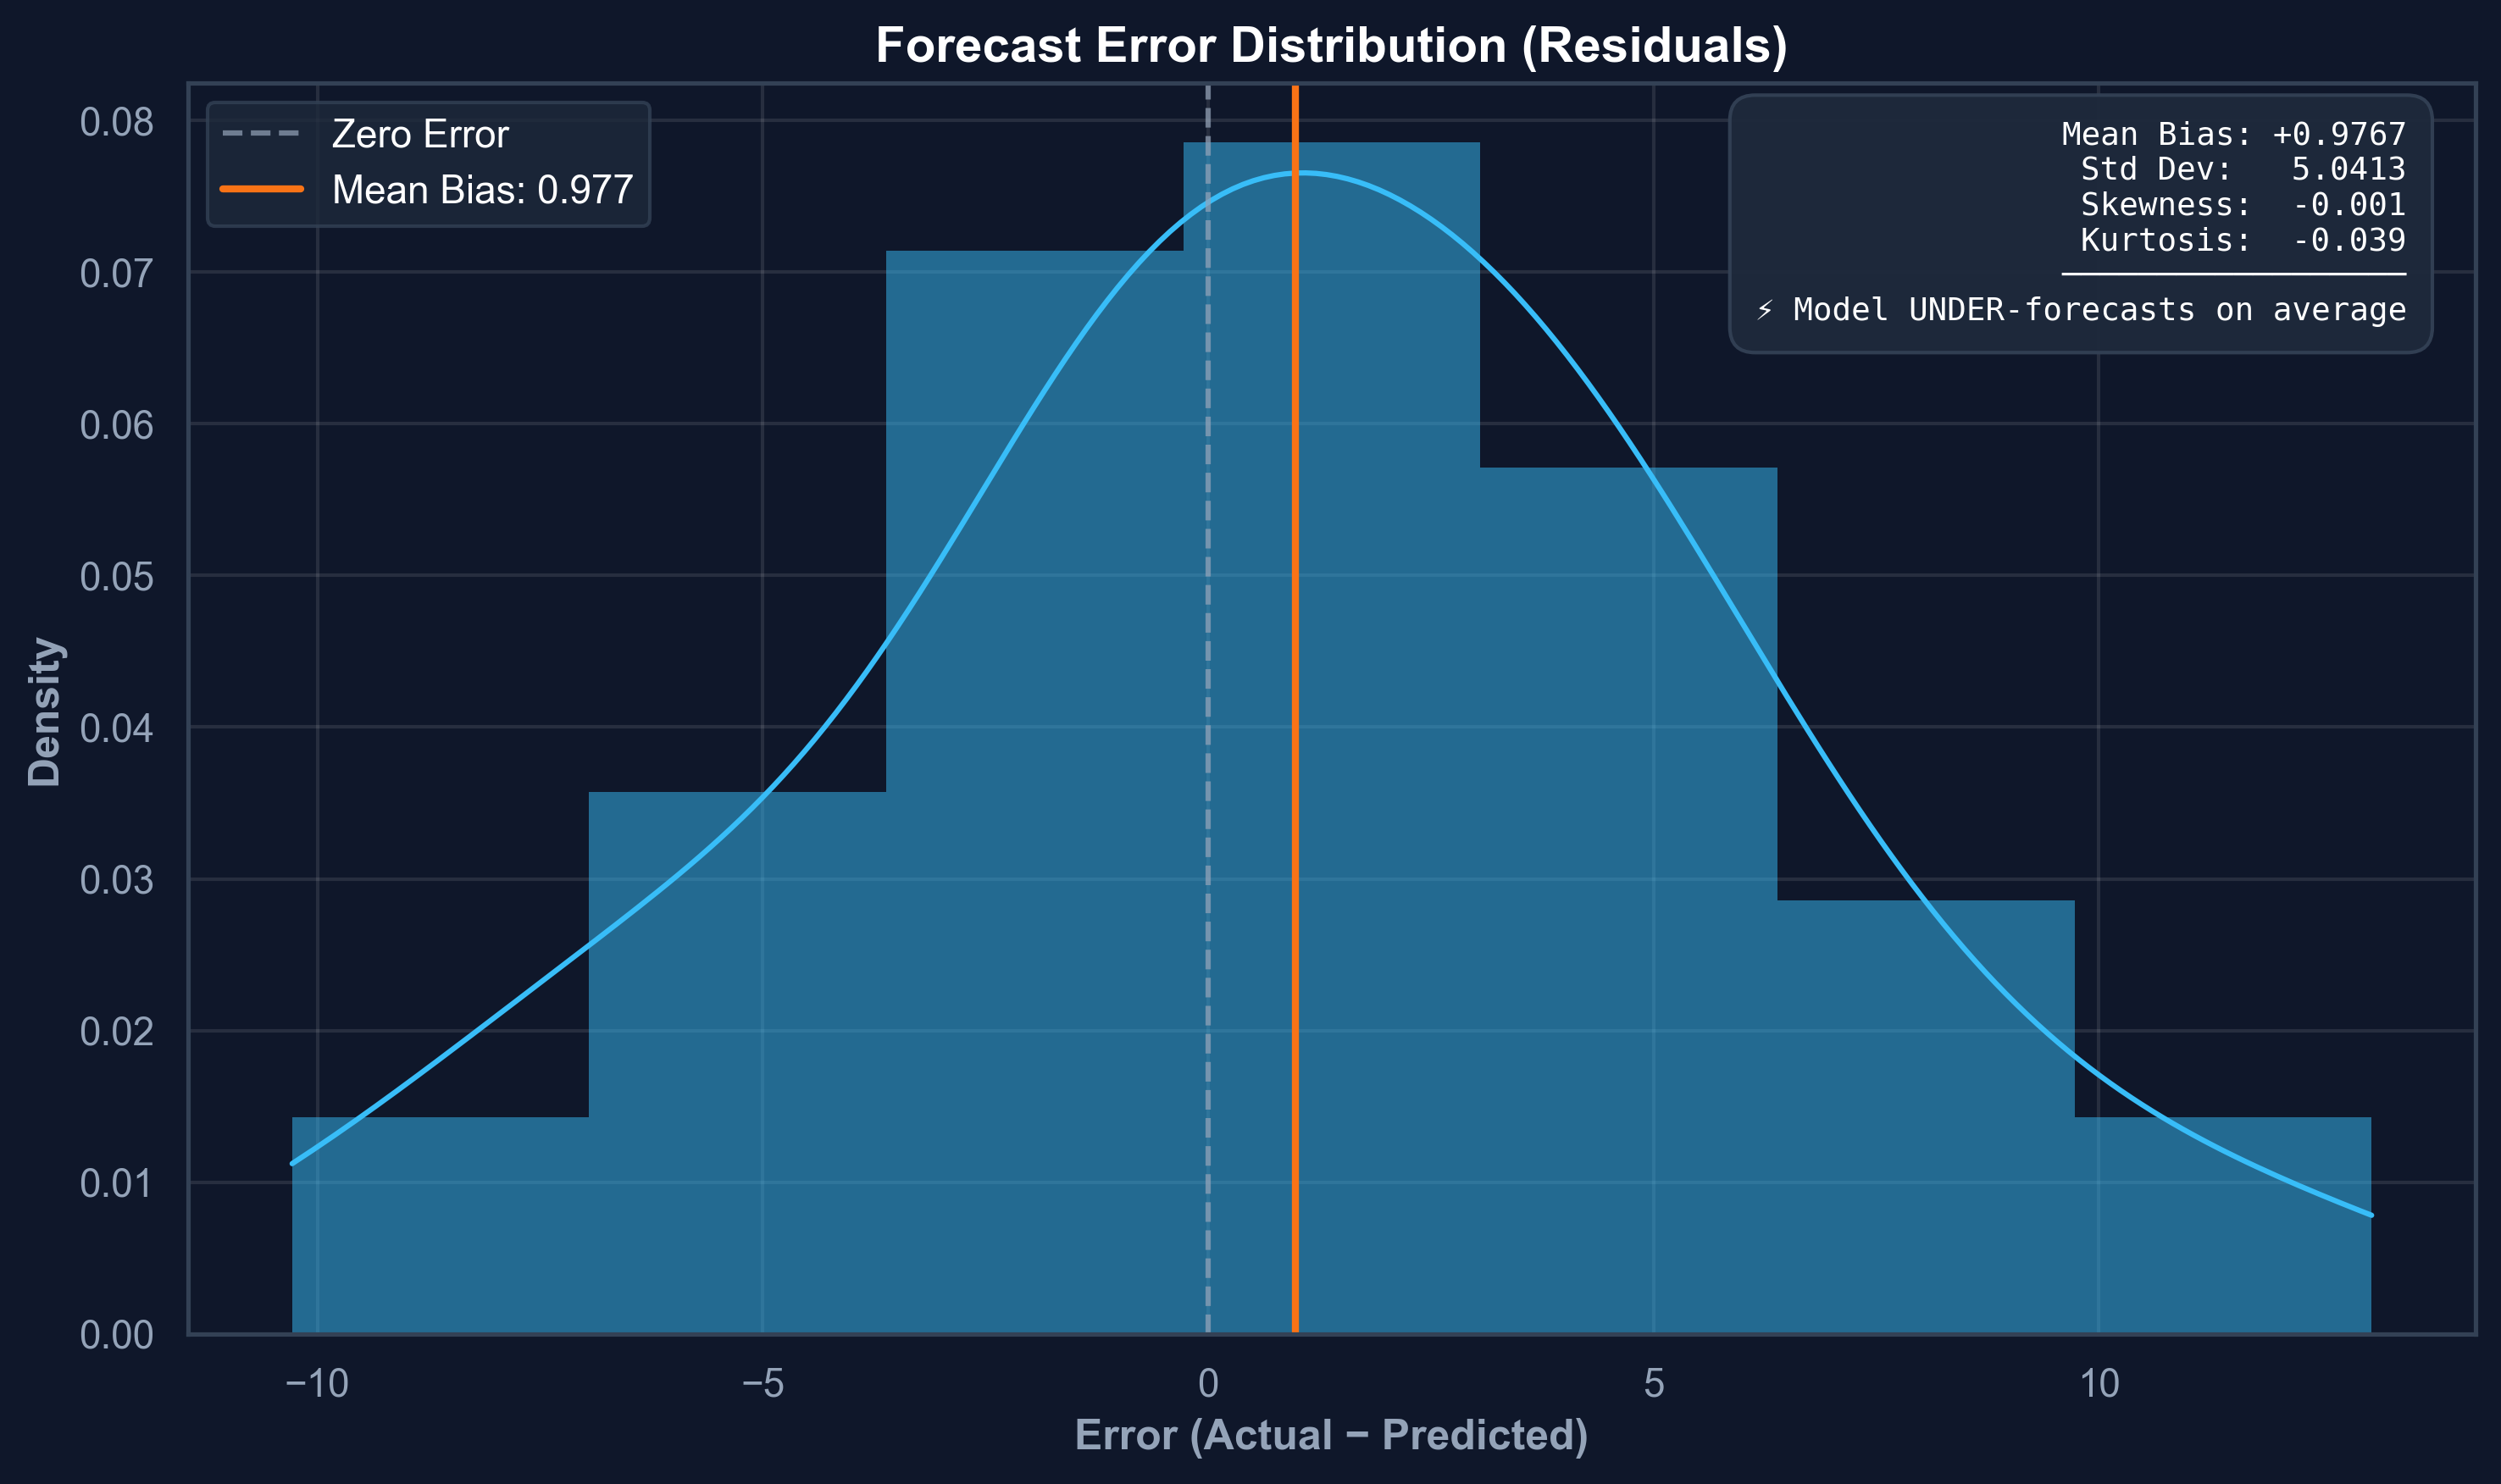
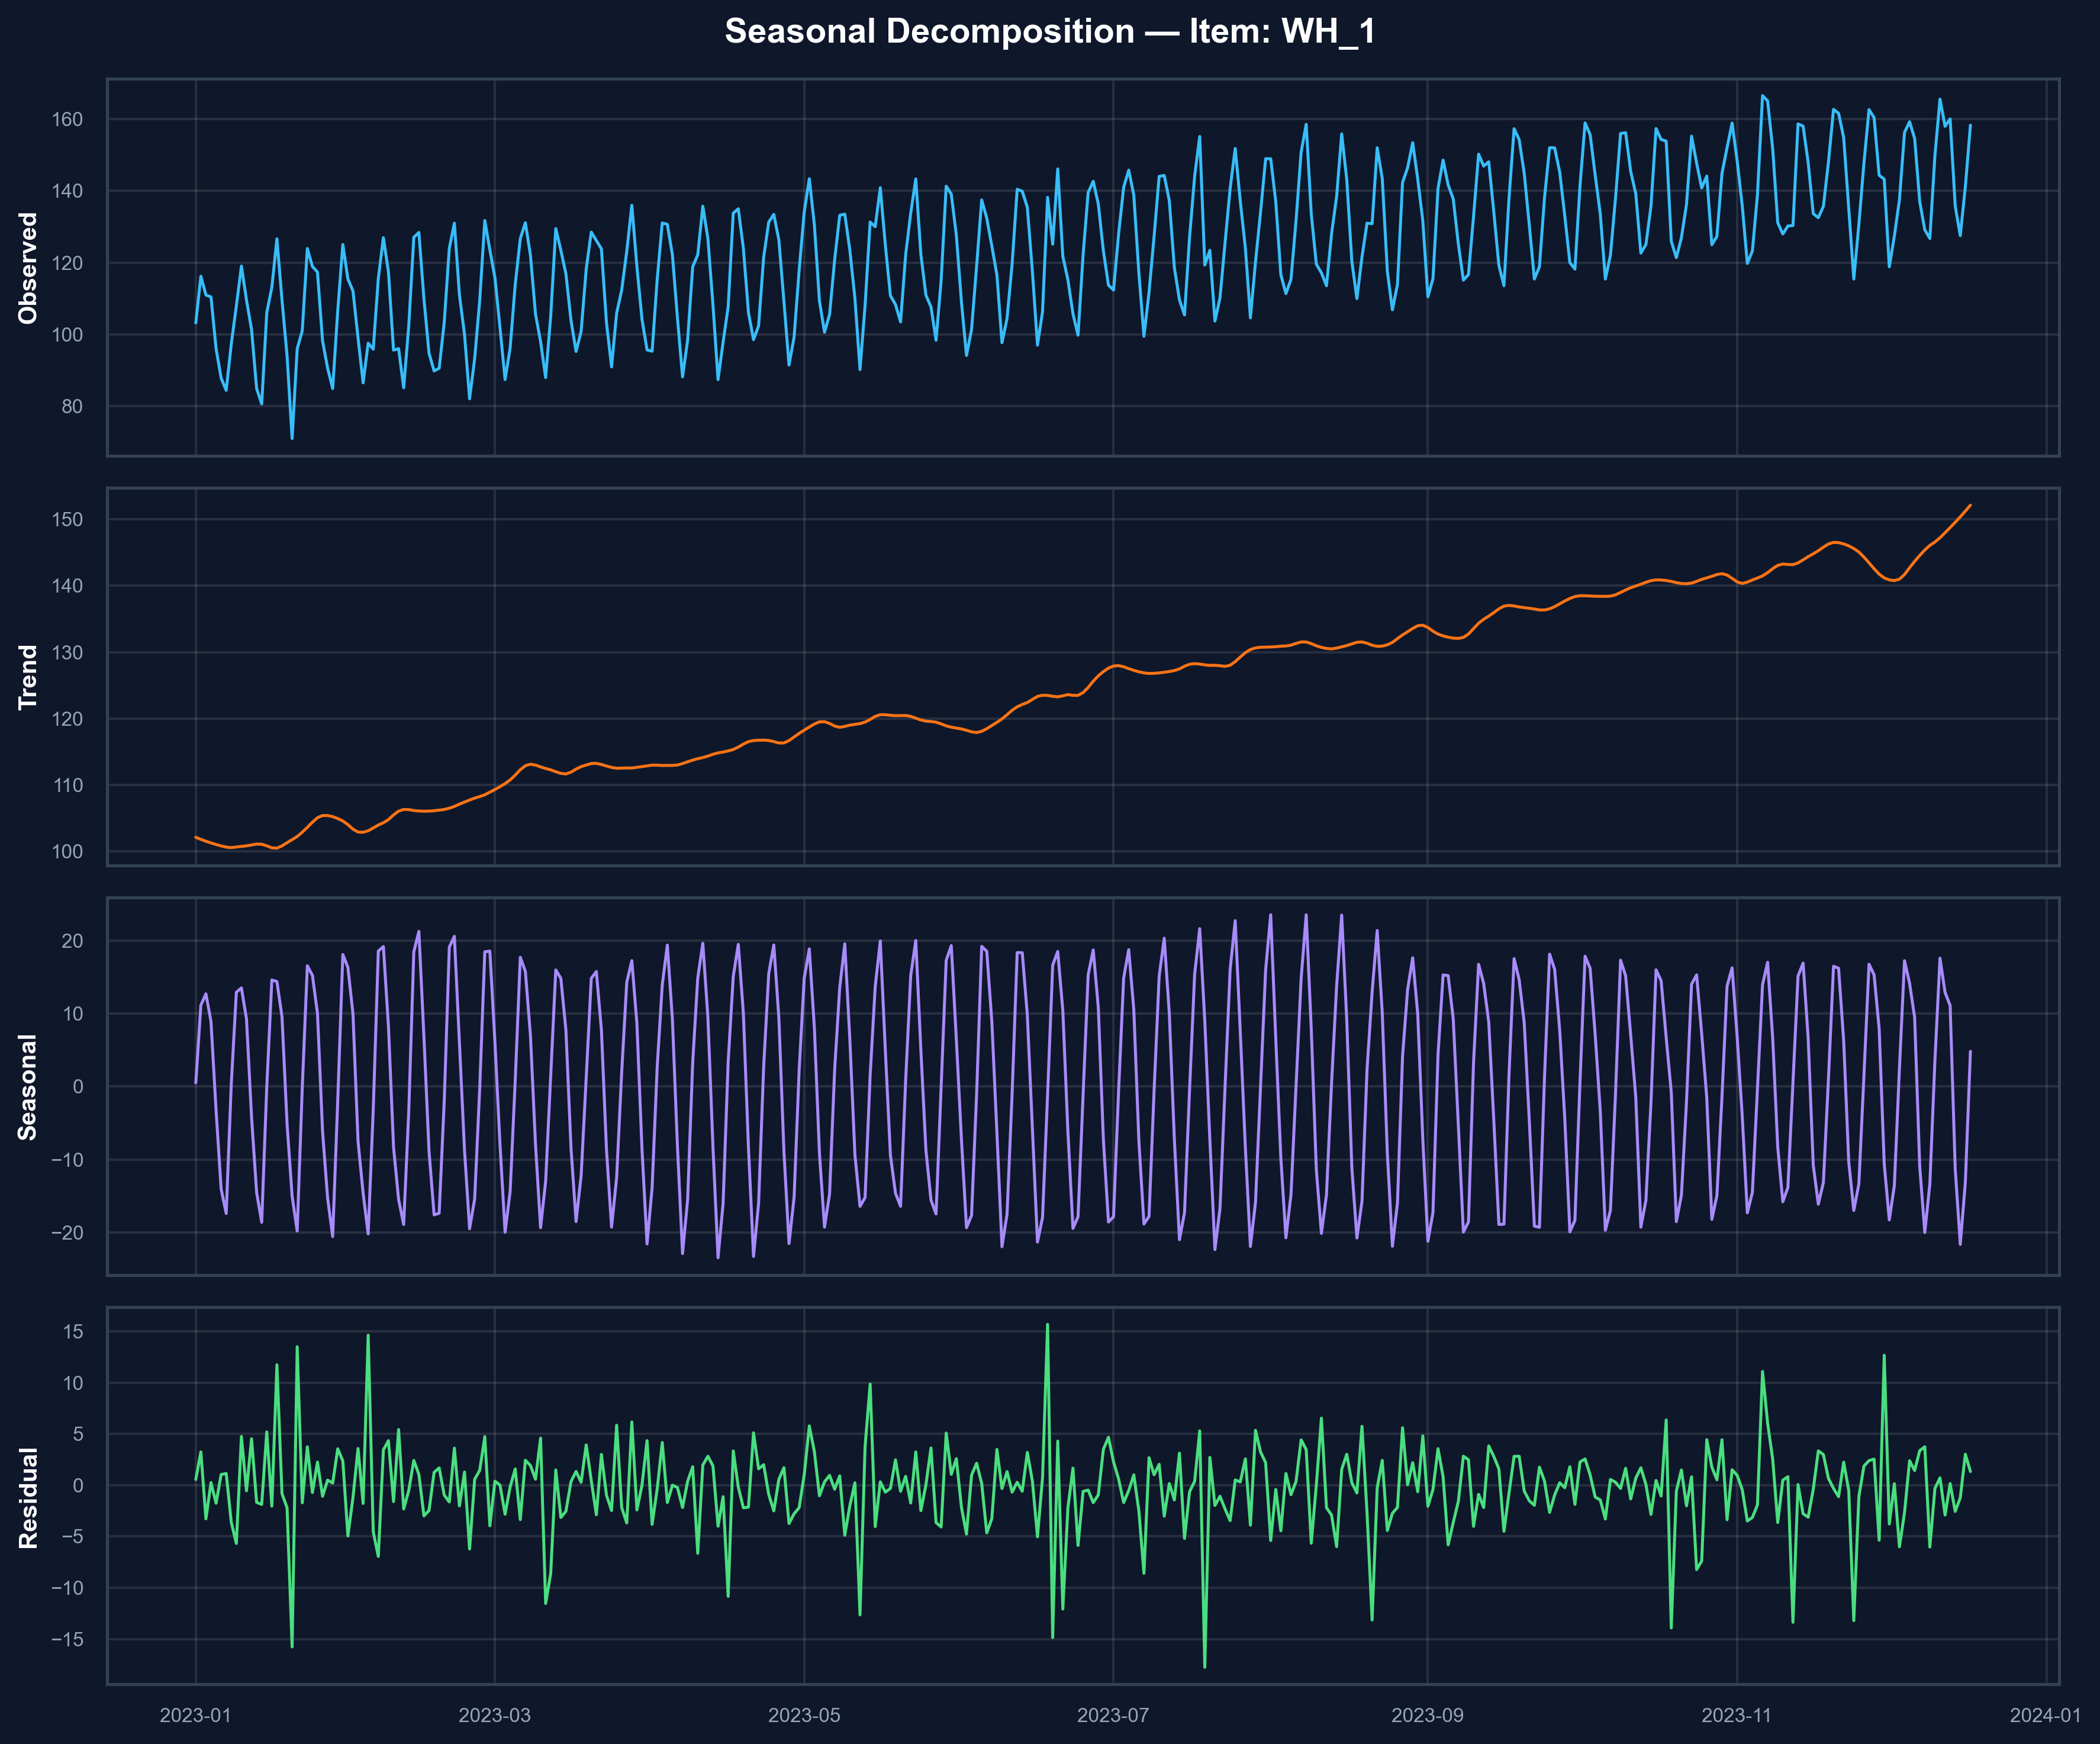
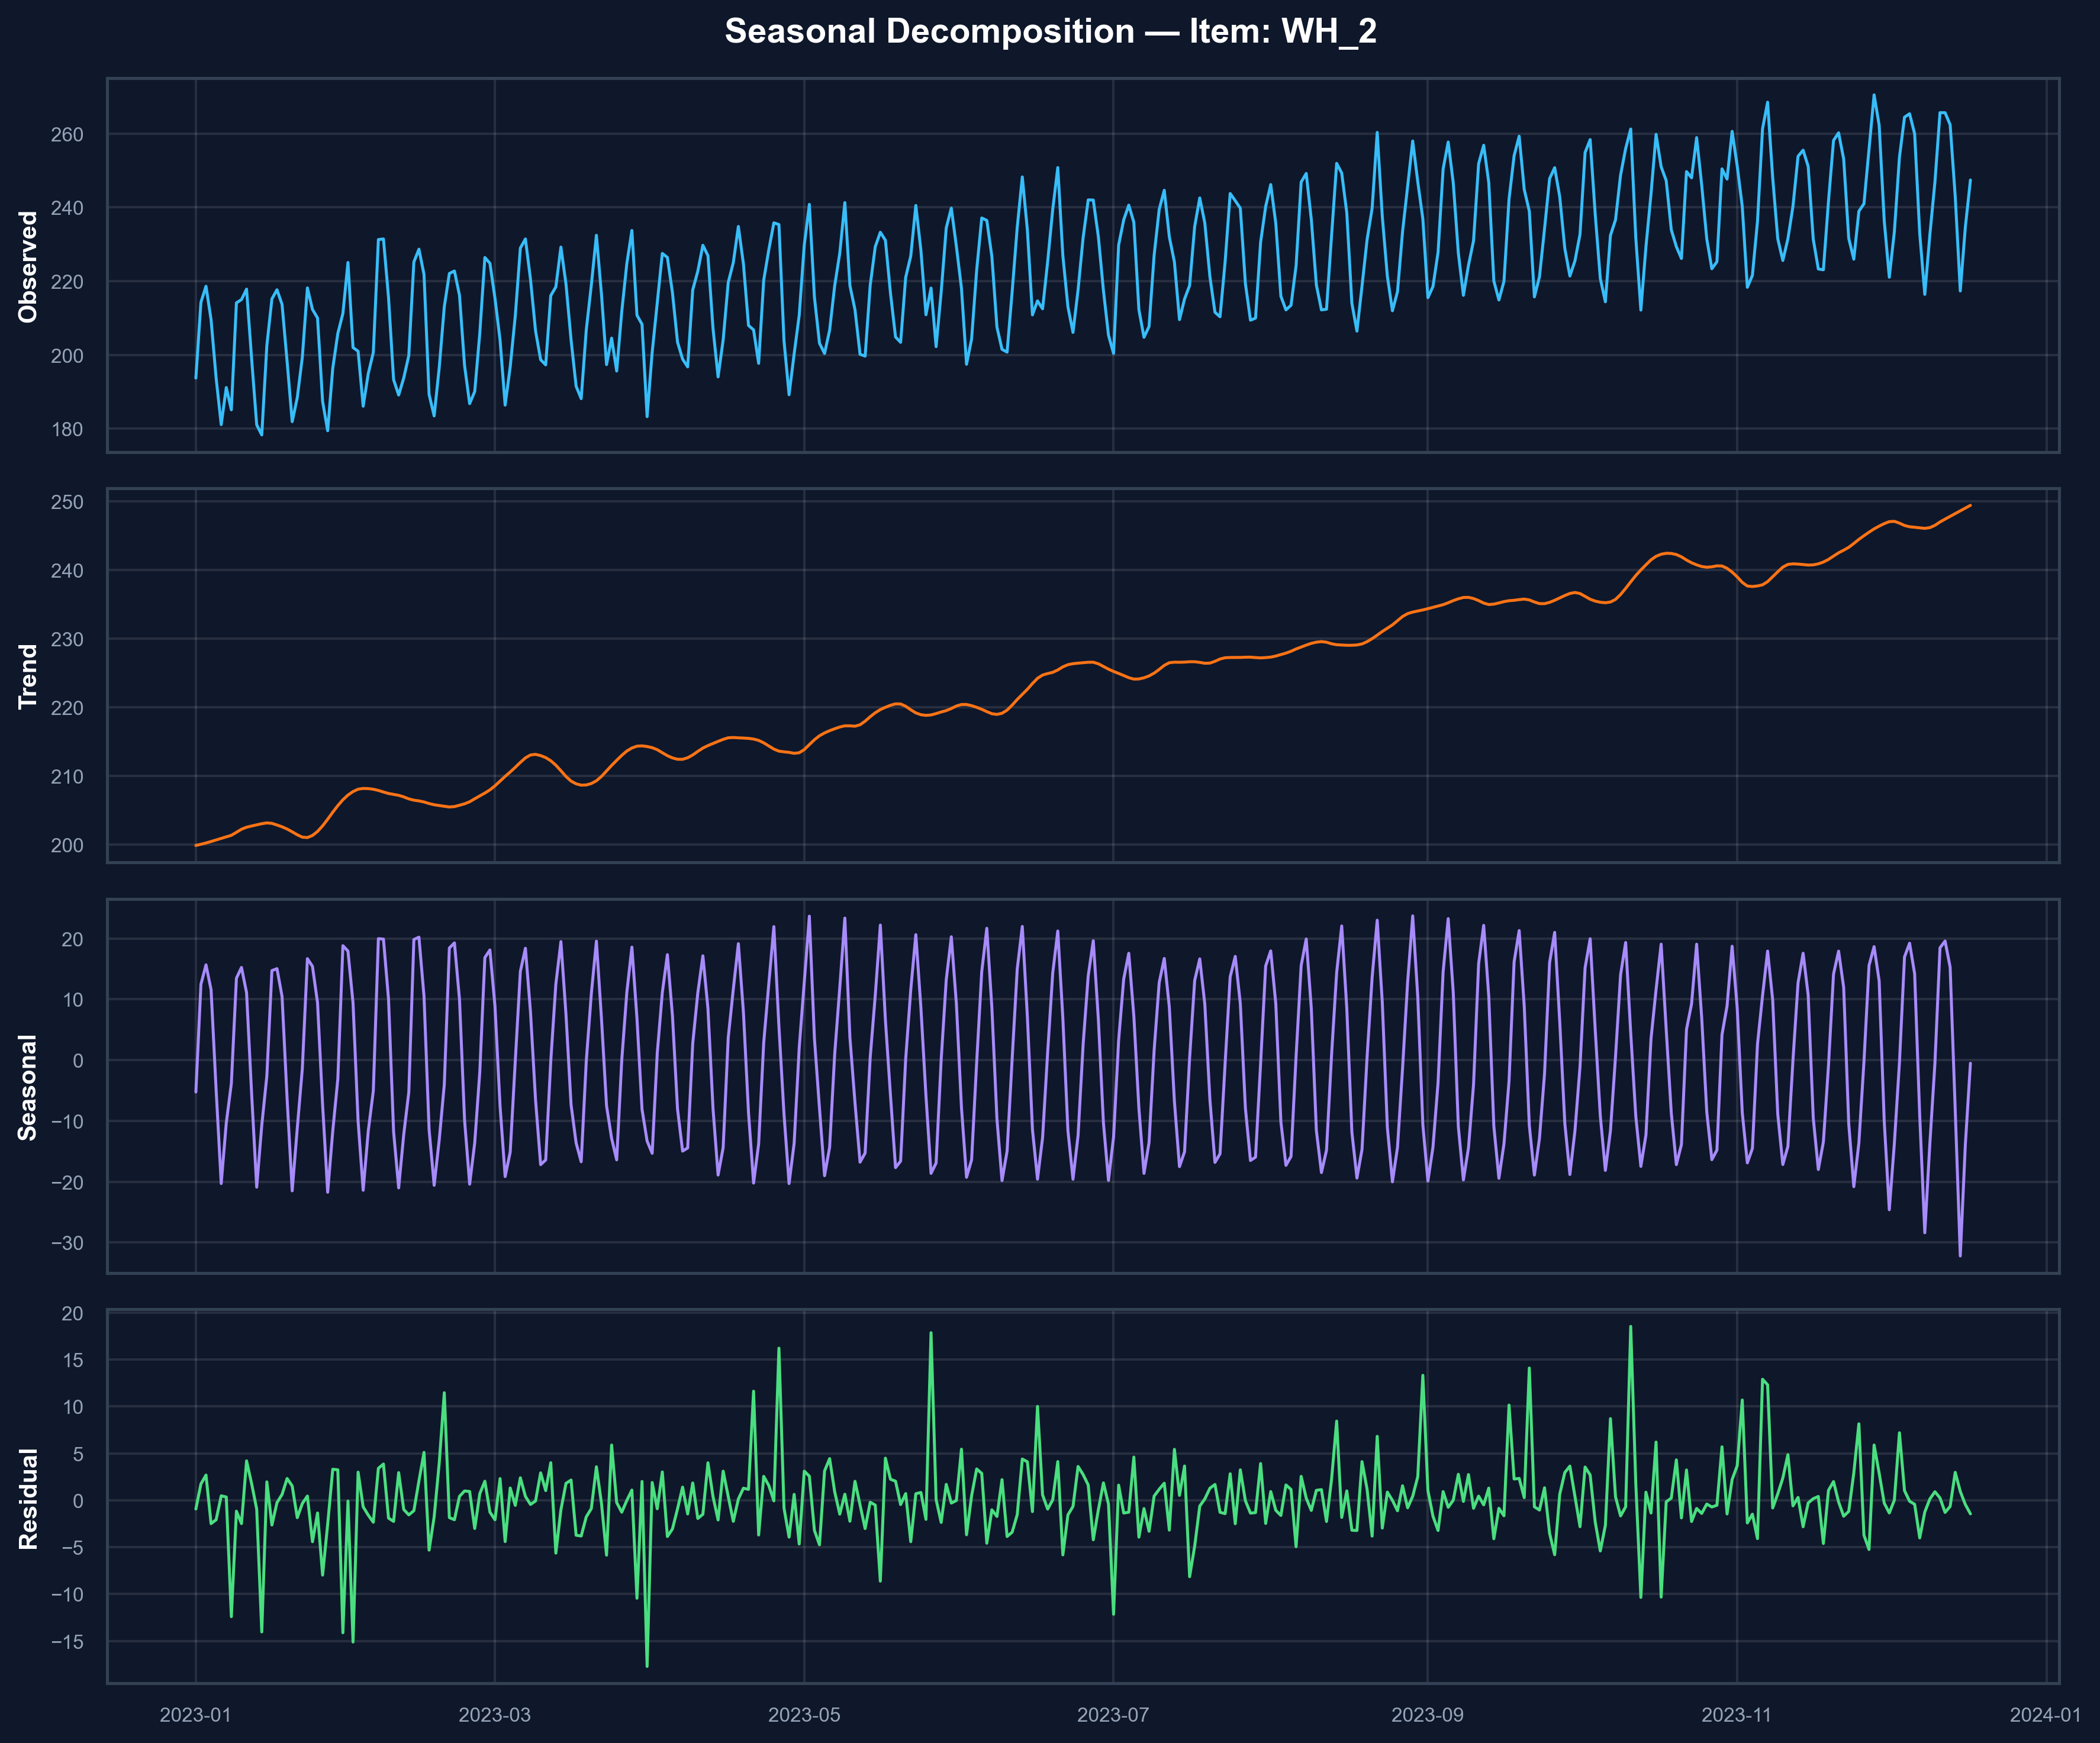
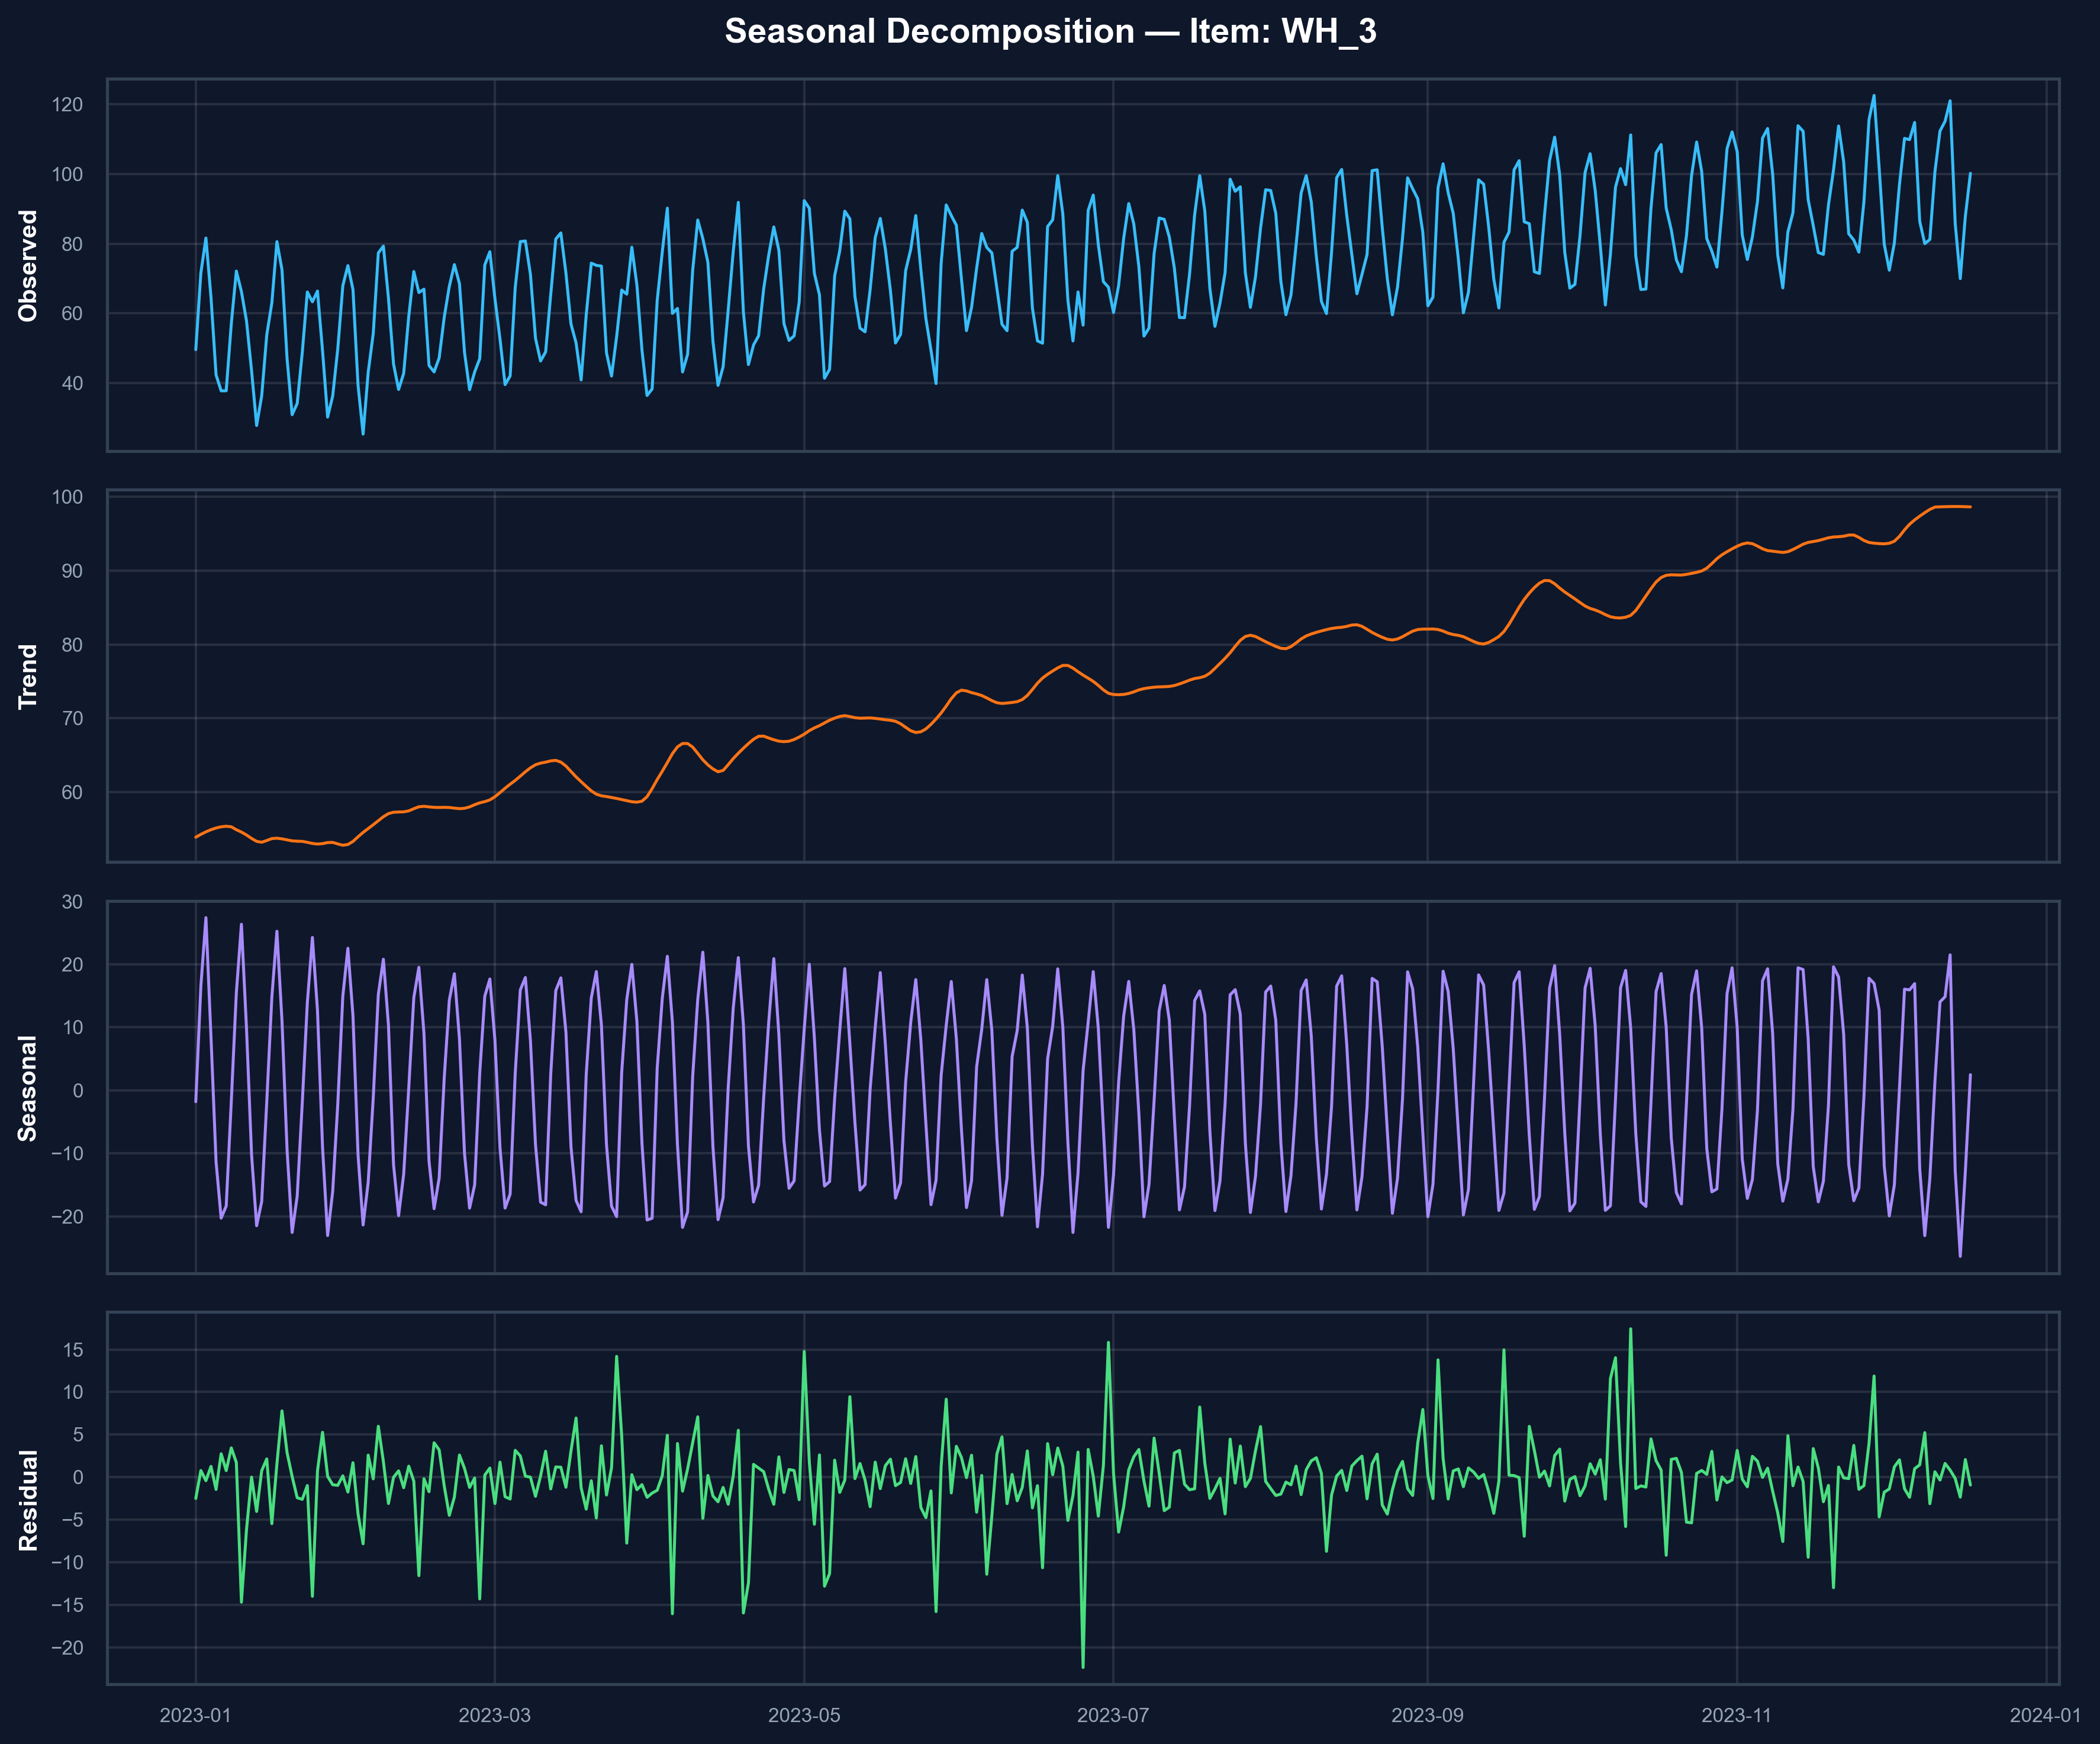

In [2]:
# ══════════════════════════════════════════════════════════════════════
#  Execution
# ══════════════════════════════════════════════════════════════════════

from ml_engine import AutoMLFactory

factory = AutoMLFactory(AUTOML_CONFIG)
factory.execute_pipeline()

---
## 🔮 Step 3: Batch Inference (Optional)
If `prediction_data_path` is defined in the config, you can run batch forecasting. Results are exported to `{base_output_dir}/predictions/batch_results.csv`.

In [3]:
# ══════════════════════════════════════════════════════════════════════
#  Batch Inference
# ══════════════════════════════════════════════════════════════════════

# if AUTOML_CONFIG.get("prediction_data_path"):
#     factory.predict_and_export()
